In [10]:
from applied.data_processing import (
    load_operating_data,
    load_product_data,
    prepare_operating_timeseries,
    compute_product_rate,
)

In [11]:
from pathlib import Path
from tsfresh.utilities.dataframe_functions import impute
import numpy as np


# --------------------------------------------------
# Load Data
# --------------------------------------------------

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

rate_df = compute_product_rate(op_df, prod_df)

op_df_new = prepare_operating_timeseries(
    op_df,
    add_tier=False,
    resample_rule="30min"
)

op_df_new = op_df_new.reset_index()
op_df_new = op_df_new[op_df_new["Batch"] != 4053]
# op_df_new = op_df_new.drop(columns=["productivity_rank"])

op_df_new = op_df_new.replace([np.inf, -np.inf], np.nan)
op_df_new = op_df_new.fillna(0)

In [12]:
op_df_new

,productivity_rank,Batch,Date and time,pH,OXYGEN,TOTAL_LIQUID_INFLOW,TOTAL_GAS_INFLOW,MEAN_OFFGAS,MEAN_PRESSURE
0,1,4041,2020-03-18 09:30:00,6.165000,8.820000,15994.080000,7586.485000,28.050000,3.357500
1,1,4041,2020-03-18 10:00:00,5.930000,7.210000,16281.430000,7617.250000,28.395000,3.417500
2,1,4041,2020-03-18 10:30:00,5.865000,6.970000,16273.640000,7632.235000,30.920000,3.410000
3,1,4041,2020-03-18 11:00:00,5.760000,7.730000,17863.290000,7894.605000,33.127500,3.505000
4,1,4041,2020-03-18 11:30:00,5.815000,9.140000,18320.640000,8144.135000,33.732500,3.577500
...,...,...,...,...,...,...,...,...,...
27406,21,4050,2021-01-17 18:00:00,5.833333,19.345000,24720.490000,9623.195000,14.257500,3.616667
27407,21,4050,2021-01-17 18:30:00,5.698333,19.948333,25275.878333,9614.516667,9.108333,3.609167
27408,21,4050,2021-01-17 19:00:00,3.920000,8.840000,18206.250000,9217.955000,3.025833,3.620833
27409,21,4050,2021-01-17 19:30:00,3.160000,14.380000,17785.183333,7357.311667,0.743333,3.867500


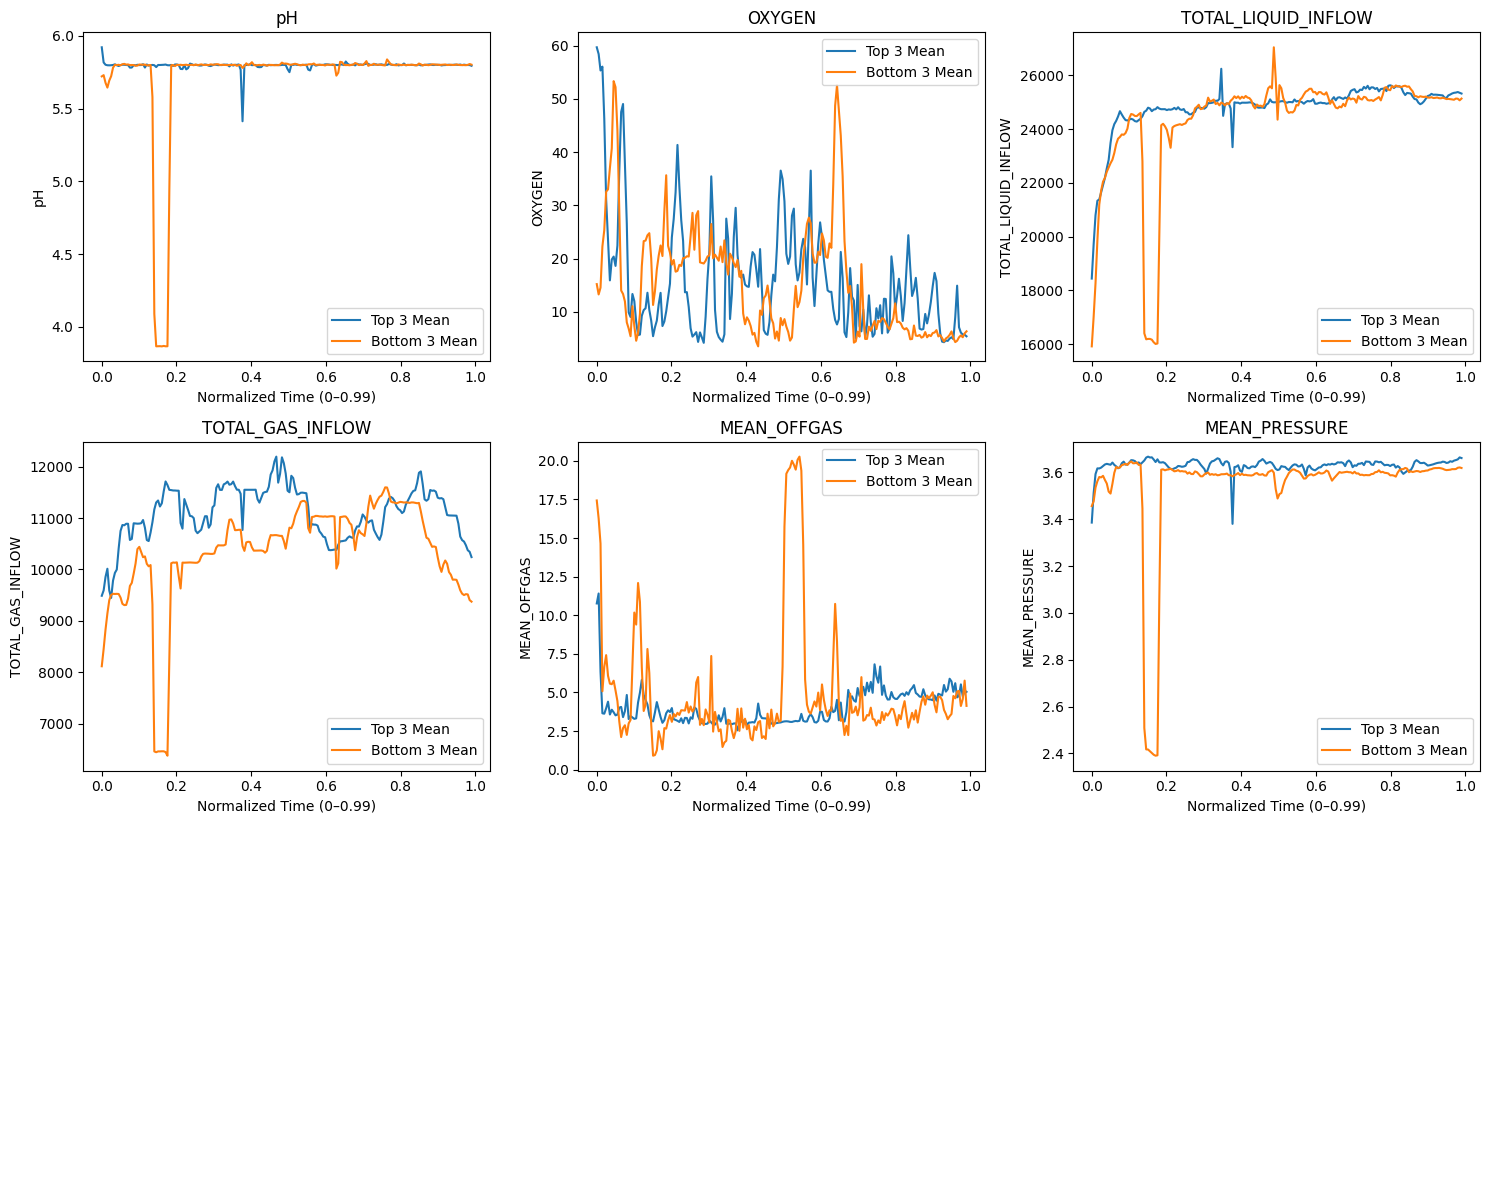

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

# -------------------------
# Variables to plot
# -------------------------
variables = [
    "pH",
    "OXYGEN",
    "TOTAL_LIQUID_INFLOW",
    "TOTAL_GAS_INFLOW",
    "MEAN_OFFGAS",
    "MEAN_PRESSURE"
]

# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_variable(df, batch_id, variable, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df[f"{variable}_smooth"] = (
        batch_df[variable]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    interp_values = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df[f"{variable}_smooth"]
    )

    return common_time, interp_values


# -------------------------
# Create 3x3 Figure
# -------------------------
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, variable in enumerate(variables):

    common_time = np.linspace(0, 1, 200)

    top_curves = []
    bottom_curves = []

    for batch in top_batches:
        _, vals = get_normalized_variable(op_df_new, batch, variable)
        top_curves.append(vals)

    for batch in bottom_batches:
        _, vals = get_normalized_variable(op_df_new, batch, variable)
        bottom_curves.append(vals)

    top_mean = np.mean(np.array(top_curves), axis=0)
    bottom_mean = np.mean(np.array(bottom_curves), axis=0)

    # Early 50%
    mask = common_time <= 0.99
    time_plot = common_time[mask]

    axes[i].plot(time_plot, top_mean[mask], label="Top 3 Mean")
    axes[i].plot(time_plot, bottom_mean[mask], label="Bottom 3 Mean")

    axes[i].set_title(variable)
    axes[i].set_xlabel("Normalized Time (0–0.99)")
    axes[i].set_ylabel(variable)
    axes[i].legend()

# Hide unused subplots
for j in range(len(variables), 9):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [14]:
def pressure_features(df, batch_id):
    batch = df[df["Batch"] == batch_id].copy()
    batch = batch.sort_values("Date and time")
    batch["time_norm"] = np.linspace(0, 1, len(batch))
    early = batch[batch["time_norm"] <= 0.5]

    p = early["MEAN_PRESSURE"].values

    return {
        "pressure_mean_early": np.mean(p),
        "pressure_min_early": np.min(p),
        "pressure_std_early": np.std(p),
        "pressure_drop_duration": np.sum(p < 3.2),  # threshold based on plot
        "pressure_drop_flag": int(np.min(p) < 3.0)
    }

def gas_features(df, batch_id):
    batch = df[df["Batch"] == batch_id].copy()
    batch = batch.sort_values("Date and time")
    batch["time_norm"] = np.linspace(0, 1, len(batch))
    early = batch[batch["time_norm"] <= 0.5]

    g = early["TOTAL_GAS_INFLOW"].values
    t = np.arange(len(g))

    return {
        "gas_mean_early": np.mean(g),
        "gas_slope_early": np.polyfit(t, g, 1)[0],
        "gas_min_early": np.min(g),
        "gas_drop_flag": int(np.min(g) < 8000)
    }


def offgas_features(df, batch_id):
    batch = df[df["Batch"] == batch_id].copy()
    batch = batch.sort_values("Date and time")
    batch["time_norm"] = np.linspace(0, 1, len(batch))
    early = batch[batch["time_norm"] <= 0.5]

    o = early["MEAN_OFFGAS"].values

    return {
        "offgas_mean_early": np.mean(o),
        "offgas_std_early": np.std(o),
        "offgas_peak_early": np.max(o)
    }


def ph_features(df, batch_id):
    batch = df[df["Batch"] == batch_id].copy()
    batch = batch.sort_values("Date and time")
    batch["time_norm"] = np.linspace(0, 1, len(batch))
    early = batch[batch["time_norm"] <= 0.5]

    p = early["pH"].values

    return {
        "pH_min_early": np.min(p),
        "pH_drop_flag": int(np.min(p) < 5.0)
    }

In [16]:
import pandas as pd

all_features = []

for batch in op_df_new["Batch"].unique():
    f = {}
    f.update(pressure_features(op_df_new, batch))
    f.update(gas_features(op_df_new, batch))
    f.update(offgas_features(op_df_new, batch))
    f.update(ph_features(op_df_new, batch))
    f["Batch"] = batch
    all_features.append(f)

features_df = pd.DataFrame(all_features)

In [18]:
features_df

,pressure_mean_early,pressure_min_early,pressure_std_early,pressure_drop_duration,pressure_drop_flag,gas_mean_early,gas_slope_early,gas_min_early,gas_drop_flag,offgas_mean_early,offgas_std_early,offgas_peak_early,pH_min_early,pH_drop_flag,Batch
0,3.631059,0.0000,0.201492,3,1,10872.326943,4.342951,0.000000,1,7.001889,2.738776,33.732500,0.000000,1,4041
1,3.644207,3.4000,0.029227,0,0,11857.349042,6.128647,5380.905000,1,0.499818,1.158605,10.837500,5.375000,0,4043
2,3.616093,3.4000,0.033777,0,0,10788.798325,-1.726155,6076.530000,1,3.121452,1.518057,16.402500,5.565000,0,4047
3,3.619550,3.1150,0.068220,4,0,10621.260806,3.972423,7877.800000,1,6.796807,1.544607,13.630000,3.205000,1,4040
4,2.671357,0.0000,1.594900,227,1,8032.967830,15.471019,0.000000,1,4.235148,2.834284,16.762500,0.000000,1,4042
5,3.625958,3.3950,0.029078,0,0,10428.068872,1.198697,8604.910000,0,7.162875,2.267102,19.822500,4.945000,1,4046
6,3.639962,3.3650,0.034995,0,0,11215.345437,7.854475,8576.850000,0,3.941935,3.830129,22.897500,6.510000,0,4045
7,3.588696,3.3500,0.080291,0,0,11348.538644,2.978685,7626.454000,1,1.950443,1.345192,15.311667,5.530000,0,4052
8,3.595892,3.3075,0.059205,0,0,9026.399807,2.242287,4596.130000,1,4.486441,1.175368,22.345000,5.530000,0,4034
9,3.644811,3.3650,0.041093,0,0,9758.117779,2.036422,8651.320000,0,2.505967,4.662484,43.175000,5.635000,0,4044


In [19]:
rate_df

,Batch,product_rate
0,4030,616.305179
1,4032,621.162886
2,4033,608.869223
3,4034,622.196071
4,4035,606.416985
5,4036,609.172327
6,4037,568.419365
7,4038,593.373544
8,4039,581.763278
9,4040,651.303020


In [21]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# -----------------------------
# Merge
# -----------------------------
df = features_df.merge(rate_df, on="Batch", how="inner").copy()

X = df.drop(columns=["Batch", "product_rate"])
y = df["product_rate"]

# Clean
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# -----------------------------
# Compute Pearson for each feature
# -----------------------------
results = []

for col in X.columns:
    r, p = pearsonr(X[col], y)
    
    results.append({
        "feature": col,
        "pearson_r": r,
        "p_value": p,
        "abs_r": abs(r)
    })

corr_df = pd.DataFrame(results).sort_values("abs_r", ascending=False)

print(corr_df)

                   feature  pearson_r   p_value     abs_r
10        offgas_std_early  -0.491847  0.023532  0.491847
11       offgas_peak_early  -0.458771  0.036453  0.458771
5           gas_mean_early   0.270217  0.236151  0.270217
6          gas_slope_early   0.196799  0.392534  0.196799
8            gas_drop_flag  -0.171553  0.457147  0.171553
9        offgas_mean_early   0.110651  0.633015  0.110651
13            pH_drop_flag   0.096874  0.676142  0.096874
2       pressure_std_early  -0.091391  0.693589  0.091391
7            gas_min_early   0.083580  0.718707  0.083580
1       pressure_min_early   0.069186  0.765707  0.069186
4       pressure_drop_flag  -0.062565  0.787610  0.062565
3   pressure_drop_duration   0.057008  0.806111  0.057008
12            pH_min_early   0.042949  0.853346  0.042949
0      pressure_mean_early   0.028154  0.903580  0.028154


In [22]:
X = df[["offgas_std_early", "offgas_peak_early"]]
y = df["product_rate"]

LOO RMSE: 36.98001096890533
LOO R2: -0.059728724054664895


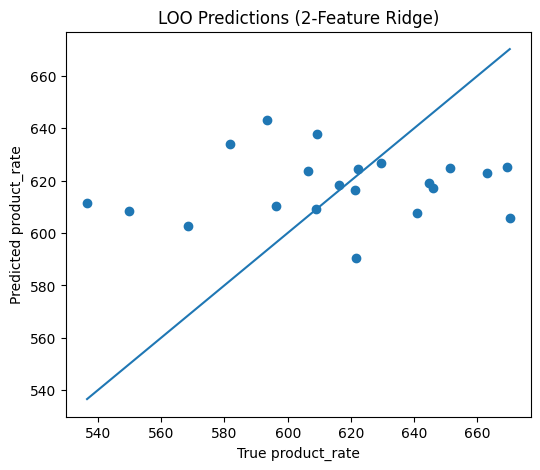


Coefficients:
             feature      coef
0   offgas_std_early -7.327797
1  offgas_peak_early -6.008644

Chosen alpha: 15.343684089300131


In [23]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# 1) X and y
# -----------------------------
X = df[["offgas_std_early", "offgas_peak_early"]].copy()
y = df["product_rate"].values

# -----------------------------
# 2) Model
# -----------------------------
alphas = np.logspace(-4, 4, 200)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas))
])

# -----------------------------
# 3) Leave-One-Out
# -----------------------------
loo = LeaveOneOut()
y_pred = cross_val_predict(model, X, y, cv=loo)

rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("LOO RMSE:", rmse)
print("LOO R2:", r2)

# -----------------------------
# 4) Plot
# -----------------------------
plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("True product_rate")
plt.ylabel("Predicted product_rate")
plt.title("LOO Predictions (2-Feature Ridge)")
plt.show()

# -----------------------------
# 5) Fit on full data for interpretation
# -----------------------------
model.fit(X, y)

ridge = model.named_steps["ridge"]

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": ridge.coef_
}).sort_values("coef")

print("\nCoefficients:")
print(coef_df)

print("\nChosen alpha:", ridge.alpha_)

In [4]:
import numpy as np
import dearpygui.dearpygui as dpg

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)


# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_variable(df, batch_id, variable, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df[f"{variable}_smooth"] = (
        batch_df[variable]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    interp_values = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df[f"{variable}_smooth"]
    )

    return common_time, interp_values


# -------------------------
# Collect TOTAL_LIQUID_INFLOW Curves
# -------------------------
common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, vals = get_normalized_variable(op_df_new, batch, "TOTAL_LIQUID_INFLOW")
    top_curves.append(vals)

for batch in bottom_batches:
    _, vals = get_normalized_variable(op_df_new, batch, "TOTAL_LIQUID_INFLOW")
    bottom_curves.append(vals)

top_curves = np.array(top_curves)
bottom_curves = np.array(bottom_curves)


# -------------------------
# Compute Mean + Std
# -------------------------
top_mean = np.mean(top_curves, axis=0)
top_std = np.std(top_curves, axis=0)

bottom_mean = np.mean(bottom_curves, axis=0)
bottom_std = np.std(bottom_curves, axis=0)


# -------------------------
# Focus on Early 50%
# -------------------------
mask = common_time <= 0.5

time_plot = common_time[mask]

top_mean_plot = top_mean[mask]
top_upper = (top_mean + top_std)[mask]
top_lower = (top_mean - top_std)[mask]

bottom_mean_plot = bottom_mean[mask]
bottom_upper = (bottom_mean + bottom_std)[mask]
bottom_lower = (bottom_mean - bottom_std)[mask]


# -------------------------
# Plot in DearPyGui
# -------------------------
dpg.create_context()

with dpg.window(label="Early TOTAL_LIQUID_INFLOW Comparison", width=1000, height=700):
    with dpg.plot(label="Top vs Bottom (Early 0–50%)", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–0.5)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="TOTAL_LIQUID_INFLOW")

        dpg.add_line_series(
            time_plot.tolist(),
            top_mean_plot.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_mean_plot.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            top_upper.tolist(),
            label="Top +1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            top_lower.tolist(),
            label="Top -1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_upper.tolist(),
            label="Bottom +1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_lower.tolist(),
            label="Bottom -1σ",
            parent=y_axis
        )

dpg.create_viewport(title="TOTAL_LIQUID_INFLOW Early Phase Comparison", width=1100, height=800)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

Top 3: [4041 4043 4047]
Bottom 3: [4050 4051 4037]


KeyboardInterrupt: 

In [7]:
import numpy as np
import dearpygui.dearpygui as dpg

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)


# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_variable(df, batch_id, variable, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df[f"{variable}_smooth"] = (
        batch_df[variable]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    interp_values = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df[f"{variable}_smooth"]
    )

    return common_time, interp_values


# -------------------------
# Collect TOTAL_GAS_INFLOW Curves
# -------------------------
common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, vals = get_normalized_variable(op_df_new, batch, "TOTAL_GAS_INFLOW")
    top_curves.append(vals)

for batch in bottom_batches:
    _, vals = get_normalized_variable(op_df_new, batch, "TOTAL_GAS_INFLOW")
    bottom_curves.append(vals)

top_curves = np.array(top_curves)
bottom_curves = np.array(bottom_curves)


# -------------------------
# Compute Mean + Std
# -------------------------
top_mean = np.mean(top_curves, axis=0)
top_std = np.std(top_curves, axis=0)

bottom_mean = np.mean(bottom_curves, axis=0)
bottom_std = np.std(bottom_curves, axis=0)


# -------------------------
# Focus on Early 50%
# -------------------------
mask = common_time <= 0.5

time_plot = common_time[mask]

top_mean_plot = top_mean[mask]
top_upper = (top_mean + top_std)[mask]
top_lower = (top_mean - top_std)[mask]

bottom_mean_plot = bottom_mean[mask]
bottom_upper = (bottom_mean + bottom_std)[mask]
bottom_lower = (bottom_mean - bottom_std)[mask]


# -------------------------
# Plot in DearPyGui
# -------------------------
dpg.create_context()

with dpg.window(label="Early TOTAL_GAS_INFLOW Comparison", width=1000, height=700):
    with dpg.plot(label="Top vs Bottom (Early 0–50%)", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–0.5)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="TOTAL_GAS_INFLOW")

        dpg.add_line_series(
            time_plot.tolist(),
            top_mean_plot.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_mean_plot.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            top_upper.tolist(),
            label="Top +1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            top_lower.tolist(),
            label="Top -1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_upper.tolist(),
            label="Bottom +1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_lower.tolist(),
            label="Bottom -1σ",
            parent=y_axis
        )

dpg.create_viewport(title="TOTAL_GAS_INFLOW Early Phase Comparison", width=1100, height=800)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

Top 3: [4041 4043 4047]
Bottom 3: [4050 4051 4037]


KeyboardInterrupt: 

In [15]:
def early_gas_features(df, batch_id):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")
    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    early = batch_df[batch_df["time_norm"] <= 0.5]

    gas = early["TOTAL_GAS_INFLOW"].values
    t = np.arange(len(gas))

    return {
        "Batch": batch_id,
        "gas_mean_early": np.mean(gas),
        "gas_std_early": np.std(gas),
        "gas_slope_early": np.polyfit(t, gas, 1)[0],
        "gas_auc_early": np.trapezoid(gas)
    }


import pandas as pd

# ---------------------------------------
# Compute early gas features for all batches
# ---------------------------------------
gas_feature_list = []

for batch_id in op_df_new["Batch"].unique():
    gas_feature_list.append(
        early_gas_features(op_df_new, batch_id)
    )

gas_features_df = pd.DataFrame(gas_feature_list)

# ---------------------------------------
# Align with productivity
# ---------------------------------------
prod_df = rate_df[["Batch", "product_rate"]]

gas_merged = gas_features_df.merge(prod_df, on="Batch")

from scipy.stats import spearmanr

results = []

for col in [
    "gas_mean_early",
    "gas_std_early",
    "gas_slope_early",
    "gas_auc_early"
]:
    corr, pval = spearmanr(
        gas_merged[col],
        gas_merged["product_rate"]
    )

    results.append({
        "feature": col,
        "spearman_corr": corr,
        "p_value": pval,
        "abs_corr": abs(corr)
    })

results_df = pd.DataFrame(results).sort_values(
    "abs_corr", ascending=False
)

results_df

,feature,spearman_corr,p_value,abs_corr
0,gas_mean_early,0.400000,0.072390,0.400000
3,gas_auc_early,0.335065,0.137610,0.335065
2,gas_slope_early,0.288312,0.205002,0.288312
1,gas_std_early,0.148052,0.521874,0.148052


In [ ]:
import numpy as np
import dearpygui.dearpygui as dpg

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)


# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_oxygen(df, batch_id, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df["OXYGEN_smooth"] = (
        batch_df["OXYGEN"]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    oxygen_interp = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df["OXYGEN_smooth"]
    )

    return common_time, oxygen_interp


# -------------------------
# Collect Curves
# -------------------------
common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    top_curves.append(oxy)

for batch in bottom_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    bottom_curves.append(oxy)

top_curves = np.array(top_curves)
bottom_curves = np.array(bottom_curves)

# -------------------------
# Compute Mean + Std
# -------------------------
top_mean = np.mean(top_curves, axis=0)
top_std = np.std(top_curves, axis=0)

bottom_mean = np.mean(bottom_curves, axis=0)
bottom_std = np.std(bottom_curves, axis=0)

# -------------------------
# Focus on Early 50%
# -------------------------
mask = common_time <= 0.5

time_plot = common_time[mask]

top_mean_plot = top_mean[mask]
top_upper = (top_mean + top_std)[mask]
top_lower = (top_mean - top_std)[mask]

bottom_mean_plot = bottom_mean[mask]
bottom_upper = (bottom_mean + bottom_std)[mask]
bottom_lower = (bottom_mean - bottom_std)[mask]


# -------------------------
# Plot in DearPyGui
# -------------------------
dpg.create_context()

with dpg.window(label="Early OXYGEN Comparison", width=1000, height=700):
    with dpg.plot(label="Top vs Bottom (Early 0–50%)", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–0.5)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="OXYGEN")

        # Top Mean
        dpg.add_line_series(
            time_plot.tolist(),
            top_mean_plot.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        # Bottom Mean
        dpg.add_line_series(
            time_plot.tolist(),
            bottom_mean_plot.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

        # Std Bands (lighter lines)
        dpg.add_line_series(
            time_plot.tolist(),
            top_upper.tolist(),
            label="Top +1σ",
            parent=y_axis
        )
        dpg.add_line_series(
            time_plot.tolist(),
            top_lower.tolist(),
            label="Top -1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_upper.tolist(),
            label="Bottom +1σ",
            parent=y_axis
        )
        dpg.add_line_series(
            time_plot.tolist(),
            bottom_lower.tolist(),
            label="Bottom -1σ",
            parent=y_axis
        )

dpg.create_viewport(title="OXYGEN Early Phase Comparison", width=1100, height=800)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

Top 3: [4041 4043 4047]
Bottom 3: [4050 4051 4037]


In [ ]:
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)

import numpy as np

def get_normalized_oxygen(df, batch_id, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    # Normalize time to 0–1
    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    # Smooth OXYGEN
    batch_df["OXYGEN_smooth"] = (
        batch_df["OXYGEN"]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    # Interpolate onto fixed grid
    common_time = np.linspace(0, 1, n_points)
    oxygen_interp = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df["OXYGEN_smooth"]
    )

    return common_time, oxygen_interp

common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    top_curves.append(oxy)

for batch in bottom_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    bottom_curves.append(oxy)

top_mean = np.mean(top_curves, axis=0)
bottom_mean = np.mean(bottom_curves, axis=0)

import dearpygui.dearpygui as dpg

dpg.create_context()

with dpg.window(label="Mean OXYGEN Comparison", width=900, height=600):
    with dpg.plot(label="Top vs Bottom Mean OXYGEN", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–1)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="OXYGEN")

        dpg.add_line_series(
            common_time.tolist(),
            top_mean.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            common_time.tolist(),
            bottom_mean.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

dpg.create_viewport(title="OXYGEN Comparison", width=1000, height=700)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

Top 3: [4041 4043 4047]
Bottom 3: [4050 4051 4037]


In [1]:
import numpy as np
import dearpygui.dearpygui as dpg

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)


# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_oxygen(df, batch_id, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df["OXYGEN_smooth"] = (
        batch_df["OXYGEN"]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    oxygen_interp = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df["OXYGEN_smooth"]
    )

    return common_time, oxygen_interp


# -------------------------
# Collect Curves
# -------------------------
common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    top_curves.append(oxy)

for batch in bottom_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    bottom_curves.append(oxy)

top_curves = np.array(top_curves)
bottom_curves = np.array(bottom_curves)

# -------------------------
# Compute Mean + Std
# -------------------------
top_mean = np.mean(top_curves, axis=0)
top_std = np.std(top_curves, axis=0)

bottom_mean = np.mean(bottom_curves, axis=0)
bottom_std = np.std(bottom_curves, axis=0)

# -------------------------
# Focus on Early 50%
# -------------------------
mask = common_time <= 0.5

time_plot = common_time[mask]

top_mean_plot = top_mean[mask]
top_upper = (top_mean + top_std)[mask]
top_lower = (top_mean - top_std)[mask]

bottom_mean_plot = bottom_mean[mask]
bottom_upper = (bottom_mean + bottom_std)[mask]
bottom_lower = (bottom_mean - bottom_std)[mask]


# -------------------------
# Plot in DearPyGui
# -------------------------
dpg.create_context()

with dpg.window(label="Early OXYGEN Comparison", width=1000, height=700):
    with dpg.plot(label="Top vs Bottom (Early 0–50%)", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–0.5)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="OXYGEN")

        # Top Mean
        dpg.add_line_series(
            time_plot.tolist(),
            top_mean_plot.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        # Bottom Mean
        dpg.add_line_series(
            time_plot.tolist(),
            bottom_mean_plot.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

        # Std Bands (lighter lines)
        dpg.add_line_series(
            time_plot.tolist(),
            top_upper.tolist(),
            label="Top +1σ",
            parent=y_axis
        )
        dpg.add_line_series(
            time_plot.tolist(),
            top_lower.tolist(),
            label="Top -1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_upper.tolist(),
            label="Bottom +1σ",
            parent=y_axis
        )
        dpg.add_line_series(
            time_plot.tolist(),
            bottom_lower.tolist(),
            label="Bottom -1σ",
            parent=y_axis
        )

dpg.create_viewport(title="OXYGEN Early Phase Comparison", width=1100, height=800)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

NameError: name 'op_df_new' is not defined